In [2]:
#run
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
#run
import zipfile
import os

drive_path = '/content/drive/MyDrive/fakenews/DATASET'

# Unzip FNNET
fnn_zip_path = os.path.join(drive_path, 'FNNET.zip')  # Changed to 'FNNET.zip'
fnn_unzip_path = '/content/FNNET/'
os.makedirs(fnn_unzip_path, exist_ok=True)
with zipfile.ZipFile(fnn_zip_path, 'r') as zip_ref:
    zip_ref.extractall(fnn_unzip_path)

# Unzip ISOT
isot_zip_path = os.path.join(drive_path, 'ISOT.zip')  # Changed to 'ISOT.zip'
isot_unzip_path = '/content/ISOT/'
os.makedirs(isot_unzip_path, exist_ok=True)
with zipfile.ZipFile(isot_zip_path, 'r') as zip_ref:
    zip_ref.extractall(isot_unzip_path)

# Unzip LIAR
liar_zip_path = os.path.join(drive_path, 'LIAR.zip')  # Changed to 'LIAR.zip'
liar_unzip_path = '/content/LIAR/'
os.makedirs(liar_unzip_path, exist_ok=True)
with zipfile.ZipFile(liar_zip_path, 'r') as zip_ref:
    zip_ref.extractall(liar_unzip_path)

In [4]:
#run
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# run and restart the session after running this cell
!pip uninstall gensim -y
!pip uninstall numpy -y
!pip install numpy
!pip install gensim

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 94.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 

In [ ]:
import pandas as pd
import os
import re
import nltk
import ssl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report
import gc

# NLTK setup
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

try:
    word_tokenize("testing")
    stopwords.words('english')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text)).lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    return [word for word in tokens if word not in stop_words]

# --- Load & Clean Data ---
# FNNET
fnn_real = pd.read_csv('/content/FNNET/dataset/politifact_real.csv')
fnn_fake = pd.read_csv('/content/FNNET/dataset/politifact_fake.csv')
fnn_real['label'] = 1
fnn_fake['label'] = 0
df_fnn = pd.concat([fnn_real, fnn_fake])
df_fnn['cleaned_text'] = df_fnn['title'].apply(clean_text)

# ISOT
isot_real = pd.read_csv('/content/ISOT/ISOT/True.csv')
isot_fake = pd.read_csv('/content/ISOT/ISOT/Fake.csv')
isot_real['label'] = 1
isot_fake['label'] = 0
df_isot = pd.concat([isot_real, isot_fake])
df_isot['cleaned_text'] = df_isot['text'].apply(clean_text)

# LIAR
liar_train = pd.read_csv('/content/LIAR/train.tsv', sep='\t', header=None)
liar_valid = pd.read_csv('/content/LIAR/valid.tsv', sep='\t', header=None)
liar_test = pd.read_csv('/content/LIAR/test.tsv', sep='\t', header=None)
liar_df = pd.concat([liar_train, liar_valid, liar_test])
liar_df.columns = ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info',
                   'party_affiliation', 'barely_true_counts', 'false_counts',
                   'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']
liar_df['label'] = liar_df['label'].apply(lambda x: 1 if x in ['true', 'mostly-true'] else 0)
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

# Combine
df = pd.concat([df_fnn[['cleaned_text', 'label']],
                df_isot[['cleaned_text', 'label']],
                liar_df[['cleaned_text', 'label']]])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)

# --- Train Word2Vec ---
embedding_dim = 50
word2vec_model = Word2Vec(sentences=X_train, vector_size=embedding_dim, window=5, min_count=3, workers=4, sg=1)
print(f"Trained Word2Vec model with vocab size: {len(word2vec_model.wv)}")

# --- Vectorize ---
def text_to_vectors(text, model, dim):
    return [model.wv[word] if word in model.wv else np.zeros(dim) for word in text]

X_train_vec = [text_to_vectors(text, word2vec_model, embedding_dim) for text in X_train]
X_test_vec = [text_to_vectors(text, word2vec_model, embedding_dim) for text in X_test]

# Filter empty sequences
train_valid_idx = [i for i, x in enumerate(X_train_vec) if len(x) > 0]
test_valid_idx = [i for i, x in enumerate(X_test_vec) if len(x) > 0]

X_train_vec = [X_train_vec[i] for i in train_valid_idx]
X_test_vec = [X_test_vec[i] for i in test_valid_idx]
y_train = y_train.iloc[train_valid_idx]
y_test = y_test.iloc[test_valid_idx]

# Padding
max_length = 200
X_train_pad = pad_sequences(X_train_vec, maxlen=max_length, padding='post', truncating='post', dtype='float32')
X_test_pad = pad_sequences(X_test_vec, maxlen=max_length, padding='post', truncating='post', dtype='float32')

# --- Build & Train LSTM Model ---
def build_model(input_dim, max_len):
    model = Sequential()
    model.add(LSTM(64, dropout=0.2, input_shape=(max_len, input_dim)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model = build_model(embedding_dim, max_length)

# Callback
checkpoint = ModelCheckpoint("best_word2vec_model.h5", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Train
model.fit(X_train_pad, y_train, epochs=20, batch_size=128, validation_split=0.1, callbacks=[checkpoint])

# Load best model
from tensorflow.keras.models import load_model
best_model = load_model("best_word2vec_model.h5")

# Evaluate
loss, acc = best_model.evaluate(X_test_pad, y_test)
print(f"Best Word2Vec LSTM Test Accuracy: {acc:.4f}")

# Classification report
y_pred = (best_model.predict(X_test_pad) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

# Save final models
best_model.save("final_word2vec_lstm_model.h5")
word2vec_model.save("word2vec.model")

print("✅ Word2Vec LSTM model and gensim model saved.")
gc.collect()



In [ ]:


zip_file_path = "/content/drive/MyDrive/FAKENEWS/glove.6B.zip"  # Replace with your actual path
extraction_path = "/content/drive/MyDrive/FAKENEWS/glove"

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Successfully unzipped to '{extraction_path}'")
    glove_file = "/content/glove.6B.100d.txt" # Assuming the .txt file is directly in the zip
    print(f"GLOVE file path: {glove_file}")
except FileNotFoundError as e:
    print(f"Error: File not found - {e}")
except zipfile.BadZipFile as e:
    print(f"Error: Invalid zip file - {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully unzipped to '/content/drive/MyDrive/FAKENEWS/glove'
GLOVE file path: /content/glove.6B.100d.txt


In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

import pandas as pd
import os
import re
import nltk
import ssl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

import gc

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download NLTK resources if not already present
try:
    word_tokenize("testing")
    stopwords.words('english')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text)).lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Load and preprocess datasets (as before - limiting data for now)
fnn_real_path = os.path.join('/content/FNNET', 'dataset', 'politifact_real.csv')
fnn_fake_path = os.path.join('/content/FNNET', 'dataset', 'politifact_fake.csv')
fnn_real_df = pd.read_csv(fnn_real_path)
fnn_fake_df = pd.read_csv(fnn_fake_path)
fnn_real_df['label'] = 1
fnn_fake_df['label'] = 0
df_fnn = pd.concat([fnn_real_df, fnn_fake_df], ignore_index=True)
df_fnn['cleaned_text'] = df_fnn['title'].apply(clean_text)
isot_real_path = os.path.join('/content/ISOT', 'ISOT', 'True.csv')
isot_fake_path = os.path.join('/content/ISOT', 'ISOT', 'Fake.csv')
isot_real_df = pd.read_csv(isot_real_path)
isot_fake_df = pd.read_csv(isot_fake_path)
isot_real_df['label'] = 1
isot_fake_df['label'] = 0
isot_df = pd.concat([isot_real_df, isot_fake_df], ignore_index=True)
isot_df['cleaned_text'] = isot_df['text'].apply(clean_text)
liar_train_path = os.path.join('/content/LIAR', 'train.tsv')
liar_valid_path = os.path.join('/content/LIAR', 'valid.tsv')
liar_test_path = os.path.join('/content/LIAR', 'test.tsv')
liar_train_df = pd.read_csv(liar_train_path, sep='\t', header=None)
liar_valid_df = pd.read_csv(liar_valid_path, sep='\t', header=None)
liar_test_df = pd.read_csv(liar_test_path, sep='\t', header=None)
liar_df = pd.concat([liar_train_df, liar_valid_df, liar_test_df], ignore_index=True)
liar_df.columns = ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']
def map_liar_label(label):
  if label in ['true', 'mostly-true']:
    return 1
  else:
    return 0
liar_df['label'] = liar_df['label'].apply(map_liar_label)
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)
df = pd.concat([df_fnn[['cleaned_text', 'label']], isot_df[['cleaned_text', 'label']], liar_df[['cleaned_text', 'label']]], ignore_index=True)


sample_size = 0.6
df_sampled = df.sample(frac=sample_size, random_state=42)
X_train_texts_sampled, X_test_texts_sampled, y_train_sampled, y_test_sampled = train_test_split(
    df_sampled['cleaned_text'], df_sampled['label'], test_size=0.2, random_state=42
)
del df, df_fnn, isot_df, liar_df, fnn_real_df, fnn_fake_df, isot_real_df, isot_fake_df, liar_train_df, liar_valid_df, liar_test_df
gc.collect()

# --- GLOVE Model (Direct Embedding Layer Approach) ---
print("\n--- GLOVE Model (Direct Embedding Layer Approach) ---")
glove_file = "/content/drive/MyDrive/FAKENEWS/glove/glove.6B.50d.txt"
embedding_dim_glove = 50
max_vocabulary_size = 5000

embeddings_index = {}
try:
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print("Loaded GLOVE embeddings (50d).")
except FileNotFoundError:
    print(f"Error: GLOVE file not found at {glove_file}. Make sure you have uploaded and specified the correct path.")
    exit()

# Create tokenizer and vocabulary
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=max_vocabulary_size, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_texts_sampled)
word_index_glove = tokenizer.word_index



# --- Save the GLOVE tokenizer ---
import pickle
# No need to import Tokenizer again, it's already imported

with open('glove_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)  # Use the 'tokenizer' variable

print("GLOVE tokenizer saved as glove_tokenizer.pkl")

# Create embedding matrix
num_words = min(max_vocabulary_size, len(word_index_glove)) + 1
embedding_matrix_glove = np.zeros((num_words, embedding_dim_glove))
for word, i in word_index_glove.items():
    if i > max_vocabulary_size:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix_glove[i] = embedding_vector

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_texts_sampled)
X_test_sequences = tokenizer.texts_to_sequences(X_test_texts_sampled)

# Pad sequences
max_length_glove = 200 # Setting a fixed max length for simplicity
X_train_padded_glove = pad_sequences(X_train_sequences, maxlen=max_length_glove, padding='post', truncating='post')
X_test_padded_glove = pad_sequences(X_test_sequences, maxlen=max_length_glove, padding='post', truncating='post')

print("Shape of X_train_padded_glove:", X_train_padded_glove.shape)
print("Shape of X_test_padded_glove:", X_test_padded_glove.shape)

# LSTM Model Building
model_glove = Sequential()
model_glove.add(Embedding(num_words, embedding_dim_glove, weights=[embedding_matrix_glove], trainable=False, input_length=max_length_glove))
model_glove.add(LSTM(32))
model_glove.add(Dense(1, activation='sigmoid'))
model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define ModelCheckpoint callback
from tensorflow.keras.callbacks import ModelCheckpoint
filepath = "best_glove_model.h5"
checkpoint = ModelCheckpoint(filepath=filepath,
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)
callbacks_list = [checkpoint]

# Train the model with more epochs and the callback
epochs = 30
batch_size = 64
model_glove.fit(X_train_padded_glove, y_train_sampled, epochs=epochs, batch_size=batch_size, validation_split=0.1, callbacks=callbacks_list)

# Load the best model
best_glove_model = tf.keras.models.load_model(filepath)

# Evaluate the best model
loss, accuracy = best_glove_model.evaluate(X_test_padded_glove, y_test_sampled)
print(f'Best GLOVE LSTM Test Accuracy: {accuracy}')

# Save the best model (redundant as ModelCheckpoint already saves, but for clarity)
best_glove_model.save('best_fake_news_lstm_glove.h5')
print("Best GLOVE LSTM Model saved as best_fake_news_lstm_glove.h5")

# Clear memory
del embeddings_index, embedding_matrix_glove, tokenizer, model_glove, X_train_sequences, X_test_sequences, X_train_padded_glove, X_test_padded_glove, best_glove_model
gc.collect()

print("\nCompleted GLOVE model training and saving the best model based on validation accuracy.")





--- GLOVE Model (Direct Embedding Layer Approach) ---
Loaded GLOVE embeddings (50d).
GLOVE tokenizer saved as glove_tokenizer.pkl
Shape of X_train_padded_glove: (28197, 200)
Shape of X_test_padded_glove: (7050, 200)
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


392/397 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7013 - loss: 0.5674
Epoch 1: val_accuracy improved from -inf to 0.77624, saving model to best_glove_model.h5


397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7021 - loss: 0.5667 - val_accuracy: 0.7762 - val_loss: 0.4715
Epoch 2/30
392/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7820 - loss: 0.4735
Epoch 2: val_accuracy did not improve from 0.77624
397/397 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7816 - loss: 0.4740 - val_accuracy: 0.6897 - val_loss: 0.5768
Epoch 3/30
392/397 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7643 - loss: 0.5085
Epoch 3: val_accuracy improved from 0.77624 to 0.84043, saving model to best_glove_model.h5


397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7649 - loss: 0.5078 - val_accuracy: 0.8404 - val_loss: 0.3969
Epoch 4/30
395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7239 - loss: 0.5435
Epoch 4: val_accuracy did not improve from 0.84043
397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7240 - loss: 0.5434 - val_accuracy: 0.7773 - val_loss: 0.4624
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7808 - loss: 0.4672
Epoch 5: val_accuracy did not improve from 0.84043
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7807 - loss: 0.4672 - val_accuracy: 0.8142 - val_loss: 0.4531
Epoch 6/30
392/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7684 - loss: 0.4963
Epoch 6: val_accuracy did not improve from 0.84043
397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7671 - loss: 0.4977 - val_accuracy: 0.6099 - val_loss: 0.6625
Epoch 7/30
394/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6495 - loss: 0.6294
Epoch 7: val_accuracy did not i

...

397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9060 - loss: 0.1909 - val_accuracy: 0.9057 - val_loss: 0.1893
Epoch 26/30
395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9047 - loss: 0.1889
Epoch 26: val_accuracy improved from 0.90567 to 0.90816, saving model to best_glove_model.h5


397/397 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9047 - loss: 0.1889 - val_accuracy: 0.9082 - val_loss: 0.1851
Epoch 27/30
395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9050 - loss: 0.1833
Epoch 27: val_accuracy improved from 0.90816 to 0.90887, saving model to best_glove_model.h5


397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9051 - loss: 0.1833 - val_accuracy: 0.9089 - val_loss: 0.1838
Epoch 28/30
393/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9048 - loss: 0.1860
Epoch 28: val_accuracy did not improve from 0.90887
397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9048 - loss: 0.1860 - val_accuracy: 0.9089 - val_loss: 0.1815
Epoch 29/30
393/397 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9069 - loss: 0.1824
Epoch 29: val_accuracy did not improve from 0.90887
397/397 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9069 - loss: 0.1825 - val_accuracy: 0.9074 - val_loss: 0.1851
Epoch 30/30
395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9037 - loss: 0.1842
Epoch 30: val_accuracy did not improve from 0.90887
397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9037 - loss: 0.1842 - val_accuracy: 0.9089 - val_loss: 0.1805


221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9098 - loss: 0.1864


Best GLOVE LSTM Test Accuracy: 0.9080851078033447
Best GLOVE LSTM Model saved as best_fake_news_lstm_glove.h5

Completed GLOVE model training and saving the best model based on validation accuracy.


In [ ]:
import pandas as pd
import os
import re
import nltk
import ssl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib # For saving TF-IDF model
import gc
from sklearn.metrics import classification_report

# Define _create_unverified_context if it doesn't exist
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
# Define _create_unverified_context outside the try-except block
def _create_unverified_context():
    # Implement your logic if ssl._create_unverified_context doesn't exist
    pass

# Download NLTK resources if not already present
try:
    word_tokenize("testing")
    stopwords.words('english')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text)).lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Load and preprocess datasets (as before - limiting data for consistency)
fnn_real_path = os.path.join('/content/FNNET', 'dataset', 'politifact_real.csv')
fnn_fake_path = os.path.join('/content/FNNET', 'dataset', 'politifact_fake.csv')
fnn_real_df = pd.read_csv(fnn_real_path)
fnn_fake_df = pd.read_csv(fnn_fake_path)
fnn_real_df['label'] = 1
fnn_fake_df['label'] = 0
df_fnn = pd.concat([fnn_real_df, fnn_fake_df], ignore_index=True)
df_fnn['cleaned_text'] = df_fnn['title'].apply(clean_text)
isot_real_path = os.path.join('/content/ISOT', 'ISOT', 'True.csv')
isot_fake_path = os.path.join('/content/ISOT', 'ISOT', 'Fake.csv')
isot_real_df = pd.read_csv(isot_real_path)
isot_fake_df = pd.read_csv(isot_fake_path)
isot_real_df['label'] = 1
isot_fake_df['label'] = 0
isot_df = pd.concat([isot_real_df, isot_fake_df], ignore_index=True)
isot_df['cleaned_text'] = isot_df['text'].apply(clean_text)
liar_train_path = os.path.join('/content/LIAR', 'train.tsv')
liar_valid_path = os.path.join('/content/LIAR', 'valid.tsv')
liar_test_path = os.path.join('/content/LIAR', 'test.tsv')
liar_train_df = pd.read_csv(liar_train_path, sep='\t', header=None)
liar_valid_df = pd.read_csv(liar_valid_path, sep='\t', header=None)
liar_test_df = pd.read_csv(liar_test_path, sep='\t', header=None)
liar_df = pd.concat([liar_train_df, liar_valid_df, liar_test_df], ignore_index=True)
liar_df.columns = ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']
def map_liar_label(label):
  if label in ['true', 'mostly-true']:
    return 1
  else:
    return 0
liar_df['label'] = liar_df['label'].apply(map_liar_label)
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)
df = pd.concat([df_fnn[['cleaned_text', 'label']], isot_df[['cleaned_text', 'label']], liar_df[['cleaned_text', 'label']]], ignore_index=True)

# --- REDUCING DATASET SIZE FOR RAM EFFICIENCY (Same as before) ---
sample_size = 0.5
df_sampled = df.sample(frac=sample_size, random_state=42)
X_train_texts_sampled_raw, X_test_texts_sampled_raw, y_train_sampled, y_test_sampled = train_test_split(
    df_sampled['cleaned_text'], df_sampled['label'], test_size=0.2, random_state=42
)
del df, df_fnn, isot_df, liar_df, fnn_real_df, fnn_fake_df, isot_real_df, isot_fake_df, liar_train_df, liar_valid_df, liar_test_df
gc.collect()

# Join tokens back into strings for TF-IDF
X_train_texts_joined = [" ".join(tokens) for tokens in X_train_texts_sampled_raw]
X_test_texts_joined = [" ".join(tokens) for tokens in X_test_texts_sampled_raw]

# --- TF-IDF Model (RAM Efficient with Logistic Regression) ---
print("\n--- TF-IDF Model (RAM Efficient with Logistic Regression) ---")
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit max features for RAM
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_texts_joined)
X_test_tfidf = tfidf_vectorizer.transform(X_test_texts_joined)

# --- Save the TF-IDF vectorizer ---
import joblib
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')
print("TF-IDF vectorizer saved as tfidf_vectorizer.joblib")

tfidf_model = LogisticRegression(solver='liblinear')
tfidf_model.fit(X_train_tfidf, y_train_sampled)
tfidf_accuracy = tfidf_model.score(X_test_tfidf, y_test_sampled)
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)
print(f"TF-IDF Logistic Regression Test Accuracy: {tfidf_accuracy}")
print(classification_report(y_test_sampled, y_pred_tfidf))

# Save TF-IDF model
joblib.dump(tfidf_model, 'tfidf_model.joblib')
print("TF-IDF Logistic Regression Model saved as tfidf_model.joblib")

# Clear TF-IDF model and data from RAM
del tfidf_vectorizer, X_train_tfidf, X_test_tfidf, tfidf_model, y_pred_tfidf
gc.collect()

print("\nCompleted training and saving the TF-IDF model.")


--- TF-IDF Model (RAM Efficient with Logistic Regression) ---
TF-IDF vectorizer saved as tfidf_vectorizer.joblib
TF-IDF Logistic Regression Test Accuracy: 0.8995744680851064
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      3229
           1       0.93      0.84      0.88      2646

    accuracy                           0.90      5875
   macro avg       0.90      0.89      0.90      5875
weighted avg       0.90      0.90      0.90      5875

TF-IDF Logistic Regression Model saved as tfidf_model.joblib

Completed training and saving the TF-IDF model.


In [1]:
#run test
import pandas as pd
import os
import re
import nltk
import ssl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
import joblib  # For loading TF-IDF model
from gensim.models import Word2Vec

# SSL context (for downloading NLTK data)
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download NLTK resources if not already present
try:
    word_tokenize("testing")
    stopwords.words('english')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

# Text cleaning
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text)).lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# --- Load Saved Models ---
print("\n--- Loading the Saved Models ---")
try:
    glove_model = load_model('/content/drive/MyDrive/fakenews/models/best_glove_912_model.h5')
    print("Loaded GLOVE model.")
except FileNotFoundError:
    print("Error: GLOVE model file not found.")
    exit()

try:
    loaded_word2vec_model_lstm = load_model('/content/drive/MyDrive/fakenews/models/best_word2vec_907_model.h5')
    print("Loaded Word2Vec LSTM model.")
except FileNotFoundError:
    print("Error: Word2Vec LSTM model file not found.")
    exit()

try:
    loaded_word2vec_model = Word2Vec.load('/content/drive/MyDrive/fakenews/models/word2vec_907.model')
    print("Loaded Word2Vec (gensim) model.")
except FileNotFoundError:
    print("Error: Word2Vec (gensim) model file not found.")
    exit()

try:
    tfidf_model = joblib.load('/content/drive/MyDrive/fakenews/models/tfidf_model90.joblib')
    print("Loaded TF-IDF model.")
except FileNotFoundError:
    print("Error: TF-IDF model file not found.")
    exit()

try:
    tfidf_vectorizer = joblib.load('/content/drive/MyDrive/fakenews/models/tfidf_vectorizer.joblib')
    print("Loaded TF-IDF vectorizer.")
except FileNotFoundError:
    print("Error: TF-IDF vectorizer file not found.")
    exit()

# --- Prepare tokenizer (GloVe) ---
print("\n--- Preparing Tokenizer ---")
# Load data to fit tokenizer only for GloVe (not used for TF-IDF)
fnn_real_df = pd.read_csv('/content/FNNET/dataset/politifact_real.csv')
fnn_fake_df = pd.read_csv('/content/FNNET/dataset/politifact_fake.csv')
fnn_real_df['label'] = 1
fnn_fake_df['label'] = 0
df_fnn = pd.concat([fnn_real_df, fnn_fake_df], ignore_index=True)
df_fnn['cleaned_text'] = df_fnn['title'].apply(clean_text)

isot_real_df = pd.read_csv('/content/ISOT/ISOT/True.csv')
isot_fake_df = pd.read_csv('/content/ISOT/ISOT/Fake.csv')
isot_real_df['label'] = 1
isot_fake_df['label'] = 0
isot_df = pd.concat([isot_real_df, isot_fake_df], ignore_index=True)
isot_df['cleaned_text'] = isot_df['text'].apply(clean_text)

liar_train = pd.read_csv('/content/LIAR/train.tsv', sep='\t', header=None)
liar_valid = pd.read_csv('/content/LIAR/valid.tsv', sep='\t', header=None)
liar_test = pd.read_csv('/content/LIAR/test.tsv', sep='\t', header=None)
liar_df = pd.concat([liar_train, liar_valid, liar_test], ignore_index=True)
liar_df.columns = ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']
liar_df['label'] = liar_df['label'].apply(lambda x: 1 if x in ['true', 'mostly-true'] else 0)
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

df = pd.concat([df_fnn[['cleaned_text', 'label']], isot_df[['cleaned_text', 'label']], liar_df[['cleaned_text', 'label']]], ignore_index=True)
df_sampled = df.sample(frac=0.2, random_state=42)
X_train_texts_sampled_raw = df_sampled['cleaned_text']

# Fit tokenizer for GloVe model input
glove_tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000, oov_token="<unk>")
glove_tokenizer.fit_on_texts(X_train_texts_sampled_raw)

# --- Word2Vec Helper ---
def text_to_word2vec(text, model, embedding_dim):
    vectors = []
    for word in text:
        if word in model.wv:
            vectors.append(model.wv[word])
        else:
            vectors.append(np.zeros(embedding_dim))
    return vectors

# --- Prediction Function ---
def predict_fake_news(text):
    cleaned_text = clean_text(text)
    embedding_dim_w2v = 50
    max_length_w2v = 100

    # GLOVE prediction
    glove_sequence = glove_tokenizer.texts_to_sequences([cleaned_text])
    glove_padded = pad_sequences(glove_sequence, maxlen=200, padding='post', truncating='post')
    glove_prediction = glove_model.predict(glove_padded)[0][0]

    # Word2Vec prediction
    word2vec_vectors = text_to_word2vec(cleaned_text, loaded_word2vec_model, embedding_dim_w2v)
    word2vec_padded = pad_sequences([word2vec_vectors], maxlen=max_length_w2v, padding='post', truncating='post', dtype='float32')
    word2vec_prediction = loaded_word2vec_model_lstm.predict(word2vec_padded)[0][0]

    # TF-IDF prediction
    tfidf_features = tfidf_vectorizer.transform([" ".join(cleaned_text)])
    tfidf_prediction_proba = tfidf_model.predict_proba(tfidf_features)[0][1]

    # Combine results
    combined_prediction = (glove_prediction + word2vec_prediction + tfidf_prediction_proba) / 3

    print(f"Input Text: {text}\n")
    print(f"GLOVE Prediction (Probability of Fake): {glove_prediction:.4f}")
    print(f"Word2Vec Prediction (Probability of Fake): {word2vec_prediction:.4f}")
    print(f"TF-IDF Prediction (Probability of Fake): {tfidf_prediction_proba:.4f}")
    print(f"Combined Average Prediction (Probability of Fake): {combined_prediction:.4f}")
    print(f"Combined Verdict: {'Fake' if combined_prediction > 0.4 else 'Real'}\n")

# --- Example Usage ---
new_texts = [
    "Breaking: Scientists discover new evidence of life on Mars.",
    "Unbelievable! Giant squid attacks New York City.",
    "Shocking!! fish found walking !!",
    "Shocking! Aliens found living in the White House basement."
]

for text in new_texts:
    predict_fake_news(text)



--- Loading the Saved Models ---


Loaded GLOVE model.


Loaded Word2Vec LSTM model.
Loaded Word2Vec (gensim) model.
Loaded TF-IDF model.
Loaded TF-IDF vectorizer.

--- Preparing Tokenizer ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
Input Text: Breaking: Scientists discover new evidence of life on Mars.

GLOVE Prediction (Probability of Fake): 0.2981
Word2Vec Prediction (Probability of Fake): 0.2957
TF-IDF Prediction (Probability of Fake): 0.1189
Combined Average Prediction (Probability of Fake): 0.2376
Combined Verdict: Real

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Input Text: Unbelievable! Giant squid attacks New York City.

GLOVE Prediction (Probability of Fake): 0.4468
Word2Vec Prediction (Probability of Fake): 0.3443
TF-IDF Prediction (Probability of Fake): 0.4795
Combined Average Prediction (Probability of Fake): 0.4235
Combined Verdict: Fake

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Input Text: Shocking!! fish found walking !!


In [ ]:
import joblib
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import re
import nltk
import ssl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Load resources instead of downloading
try:
    word_tokenize("testing")  # test if punkt_tab is loaded
    stopwords.words('english')  # test if stopwords are loaded.
except LookupError:
    print('NLTK resources not found. Please run the download code first.')


def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text)).lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)


# Load Datasets (rest of your data loading code remains the same)
fnn_real_path = os.path.join('/content/FNNET', 'dataset', 'politifact_real.csv')
fnn_fake_path = os.path.join('/content/FNNET', 'dataset', 'politifact_fake.csv')
fnn_real_df = pd.read_csv(fnn_real_path)
fnn_fake_df = pd.read_csv(fnn_fake_path)
fnn_real_df['label'] = 1
fnn_fake_df['label'] = 0
df_fnn = pd.concat([fnn_real_df, fnn_fake_df], ignore_index=True)
df_fnn['cleaned_text'] = df_fnn['title'].apply(clean_text)
isot_real_path = os.path.join('/content/ISOT', 'ISOT', 'True.csv')
isot_fake_path = os.path.join('/content/ISOT', 'ISOT', 'Fake.csv')
isot_real_df = pd.read_csv(isot_real_path)
isot_fake_df = pd.read_csv(isot_fake_path)
isot_real_df['label'] = 1
isot_fake_df['label'] = 0
isot_df = pd.concat([isot_real_df, isot_fake_df], ignore_index=True)
isot_df['cleaned_text'] = isot_df['text'].apply(clean_text)
liar_train_path = os.path.join('/content/LIAR', 'train.tsv')
liar_valid_path = os.path.join('/content/LIAR', 'valid.tsv')
liar_test_path = os.path.join('/content/LIAR', 'test.tsv')
liar_train_df = pd.read_csv(liar_train_path, sep='\t', header=None)
liar_valid_df = pd.read_csv(liar_valid_path, sep='\t', header=None)
liar_test_df = pd.read_csv(liar_test_path, sep='\t', header=None)
liar_df = pd.concat([liar_train_df, liar_valid_df, liar_test_df], ignore_index=True)
liar_df.columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation',
    'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']


def map_liar_label(label):
    if label in ['true', 'mostly-true']:
        return 1
    else:
        return 0


liar_df['label'] = liar_df['label'].apply(map_liar_label)
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)
df = pd.concat([df_fnn[['cleaned_text', 'label']], isot_df[['cleaned_text', 'label']], liar_df[['cleaned_text', 'label']]],
               ignore_index=True)
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)

# --- Re-fit Word2Vec Tokenizer ---
tokenizer_word2vec = Tokenizer()
tokenizer_word2vec.fit_on_texts(X_train)

# --- Define the path where you want to save the tokenizer ---
tokenizer_save_path = '/content/drive/MyDrive/FAKENEWS/models/word2vec_tokenizer_907.pkl'

# --- Save the tokenizer using joblib ---
joblib.dump(tokenizer_word2vec, tokenizer_save_path)

print(f"Word2Vec tokenizer saved successfully to: {tokenizer_save_path}")

# Now you can proceed with the rest of your evaluation script,
# loading the tokenizer from this saved path.

Word2Vec tokenizer saved successfully to: /content/drive/MyDrive/FAKENEWS/models/word2vec_tokenizer_907.pkl


In [ ]:
# Predict with all models and visualize
def predict_and_visualize(text):
    cleaned_text = clean_text(text)
    joined_text = " ".join(cleaned_text)

    # GLOVE Prediction
    glove_seq = glove_tokenizer.texts_to_sequences([cleaned_text])

    # Add a check for empty sequence before padding for GLOVE
    if len(glove_seq[0]) == 0:
        glove_pred = 0.5 # Default to 0.5 if no meaningful tokens for GLOVE
        # For consistency in visualization, use a placeholder array for padding
        glove_pad = np.zeros((1, 200)) # Match expected padded shape
    else:
        glove_pad = pad_sequences(glove_seq, maxlen=200, padding='post')
        glove_pred = glove_model.predict(glove_pad)[0][0]

    # Word2Vec Prediction
    w2v_vec = text_to_word2vec(cleaned_text, word2vec_model)
    # Add a check for empty sequence before padding for Word2Vec
    if len(w2v_vec) == 0:
         word2vec_pred = 0.5 # Default to 0.5 if no meaningful tokens for Word2Vec
         # For consistency in visualization, use a placeholder array for padding
         max_length_word2vec = 200 # Assuming this was the length used in training
         w2v_pad = np.zeros((1, max_length_word2vec, 50)) # Match expected padded shape (batch_size, max_len, embedding_dim)
    else:
        # Ensure the maxlen matches the training maxlen for Word2Vec
        max_length_word2vec = 200 # Assuming this was the length used in training
        w2v_pad = pad_sequences([w2v_vec], maxlen=max_length_word2vec, padding='post', dtype='float32')
        word2vec_pred = word2vec_lstm_model.predict(w2v_pad)[0][0]


    # TF-IDF Prediction
    tfidf_feat = tfidf_vectorizer.transform([joined_text])
    tfidf_pred = tfidf_model.predict_proba(tfidf_feat)[0][1]  # probability of class 1 (Fake)

    # Combined prediction
    combined_pred = (glove_pred + word2vec_pred + tfidf_pred) / 3

    # Print raw results
    print(f"\nInput Text:\n{text}\n")
    print(f"GLOVE Prediction: {glove_pred:.4f}")
    print(f"Word2Vec Prediction: {word2vec_pred:.4f}")
    print(f"TF-IDF Prediction: {tfidf_pred:.4f}")
    print(f"Combined Prediction: {combined_pred:.4f}")
    print(f"Verdict: {'Fake' if combined_pred > 0.5 else 'Real'}")

    # Plot
    labels = ['GLOVE', 'Word2Vec', 'TF-IDF', 'Combined']
    values = [glove_pred, word2vec_pred, tfidf_pred, combined_pred]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(labels, values, color=['skyblue', 'lightgreen', 'salmon', 'orange'])
    plt.ylim(0, 1)
    plt.axhline(y=0.5, color='red', linestyle='--', label='Fake/Real Threshold (0.5)')
    plt.title("Fake News Prediction Probabilities")
    plt.ylabel("Probability of Fake")
    plt.legend()

    # Annotate values
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

    plt.show()

In [ ]:
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

# Assuming 'tokenizer' is your fitted tokenizer object

# Define/re-initialize the tokenizer
glove_tokenizer = Tokenizer(num_words=5000, oov_token="<unk>") # Assuming num_words and oov_token values

with open('glove_tokenizer.pkl', 'wb') as f:
    pickle.dump(glove_tokenizer, f)  # Use the 'glove_tokenizer' variable

print("GLOVE tokenizer saved as glove_tokenizer.pkl")

GLOVE tokenizer saved as glove_tokenizer.pkl


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
from tensorflow import keras
from gensim.models import Word2Vec
import numpy as np
import gc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline # Import Pipeline


# Download NLTK resources if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    import nltk
    nltk.download('stopwords')

try:
    word_tokenize("example")
except LookupError:
    import nltk
    nltk.download('punkt')


stop_words = set(stopwords.words('english'))

def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\@\w+|\#', '', text)
        text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text_tokens = word_tokenize(text)
        filtered_tokens = [w for w in text_tokens if not w in stop_words]
        return " ".join(filtered_tokens)
    return ""



# --- Data Loading and Preprocessing ---
sample_size = 5000

fnn_real_path = os.path.join('/content/FNNET', 'dataset', 'politifact_real.csv')
fnn_fake_path = os.path.join('/content/FNNET', 'dataset', 'politifact_fake.csv')
fnn_real_temp_df = pd.read_csv(fnn_real_path)
fnn_fake_temp_df = pd.read_csv(fnn_fake_path)
effective_fnn_sample = min(len(fnn_real_temp_df), len(fnn_fake_temp_df), sample_size)
fnn_real_df = fnn_real_temp_df.sample(effective_fnn_sample, random_state=42)
fnn_fake_df = fnn_fake_temp_df.sample(effective_fnn_sample, random_state=42)
fnn_real_df['label'] = 1
fnn_fake_df['label'] = 0
df_fnn = pd.concat([fnn_real_df, fnn_fake_df], ignore_index=True)
df_fnn['cleaned_text'] = df_fnn['title'].apply(clean_text)

isot_real_path = os.path.join('/content/ISOT', 'ISOT', 'True.csv')
isot_fake_path = os.path.join('/content/ISOT', 'ISOT', 'Fake.csv')
isot_real_temp_df = pd.read_csv(isot_real_path)
isot_fake_temp_df = pd.read_csv(isot_fake_path)
effective_isot_sample = min(len(isot_real_temp_df), len(isot_fake_temp_df), sample_size)
isot_real_df = isot_real_temp_df.sample(effective_isot_sample, random_state=42)
isot_fake_df = isot_fake_temp_df.sample(effective_isot_sample, random_state=42)
isot_real_df['label'] = 1
isot_fake_df['label'] = 0
df_isot = pd.concat([isot_real_df, isot_fake_df], ignore_index=True)
df_isot['cleaned_text'] = df_isot['text'].apply(clean_text)


liar_train_path = os.path.join('/content/LIAR', 'train.tsv')
liar_valid_path = os.path.join('/content/LIAR', 'valid.tsv')
liar_test_path = os.path.join('/content/LIAR', 'test.tsv')
liar_train_temp_df = pd.read_csv(liar_train_path, sep='\t', header=None)
liar_valid_temp_df = pd.read_csv(liar_valid_path, sep='\t', header=None)
liar_test_temp_df = pd.read_csv(liar_test_path, sep='\t', header=None)
effective_liar_sample = min(len(liar_train_temp_df), len(liar_valid_temp_df), len(liar_test_temp_df), sample_size)
liar_train_df = liar_train_temp_df.sample(effective_liar_sample, random_state=42)
liar_valid_df = liar_valid_temp_df.sample(effective_liar_sample, random_state=42)
liar_test_df = liar_test_df.sample(effective_liar_sample, random_state=42)
liar_df = pd.concat([liar_train_df, liar_valid_df, liar_test_df], ignore_index=True)
liar_df.columns = ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']
def map_liar_label(label):
    if label in ['true', 'mostly-true']:
        return 1
    else:
        return 0
liar_df['label'] = liar_df['label'].apply(map_liar_label)
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

df = pd.concat([df_fnn[['cleaned_text', 'label']], df_isot[['cleaned_text', 'label']], liar_df[['cleaned_text', 'label']]], ignore_index=True)


# Separate features (cleaned text) and labels
X = df['cleaned_text']
y = df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# --- Model Evaluation ---
def evaluate_model(model_path, X_test, y_test, model_name, model_type='joblib', tokenizer=None):
    """
    Loads a trained model, evaluates it on the given data, and returns the accuracy.

    Args:
        model_path (str): Path to the saved model file.
        X_test (pd.Series): The test data.
        y_test (pd.Series): The true labels for the test data.
        model_name (str): Name of the model.
        model_type (str, optional): Type of the model ('joblib', 'keras', 'word2vec', 'glove').
            Defaults to 'joblib'.
        tokenizer:  Tokenizer object.

    Returns:
        float: The accuracy of the model on the test data, or None on error.
    """
    try:
        if model_type == 'joblib':
            model = joblib.load(model_path)
            if model_name == 'TF-IDF Logistic Regression':
                # No need to transform here, the pipeline handles it.
                predictions = model.predict(X_test)
            else:
                predictions = model.predict(X_test)
        elif model_type == 'keras':
            model = tf.keras.models.load_model(model_path)
            # Assuming your Keras model expects padded sequences as input
            # You'll need to adjust this based on your actual model input
            if tokenizer is None:
                raise ValueError("Tokenizer is required for Keras models.")
            X_test_sequences = tokenizer.texts_to_sequences(X_test)
            X_test_padded = tf.keras.preprocessing.sequence.pad_sequences(X_test_sequences, maxlen=100)  # Adjust maxlen
            predictions = (model.predict(X_test_padded) > 0.5).astype("int32")  # For binary classification
            predictions = predictions.flatten()
        elif model_type == 'word2vec':
            # Load Word2Vec model
            word2vec_model = Word2Vec.load(model_path)
            if tokenizer is None:
                raise ValueError("Tokenizer is required for Word2Vec models.")
            X_test_sequences = tokenizer.texts_to_sequences(X_test)
            X_test_padded = tf.keras.preprocessing.sequence.pad_sequences(X_test_sequences, maxlen=120)

            #check if the model is working
            embedding_dim = word2vec_model.vector_size
            vocabulary_size = len(tokenizer.word_index) + 1

            embedding_matrix = np.zeros((vocabulary_size, embedding_dim))
            for word, i in tokenizer.word_index.items():
                if word in word2vec_model.wv:
                    embedding_matrix[i] = word2vec_model.wv[word]


            # Define a simple LSTM model for prediction
            model = tf.keras.models.Sequential([
                tf.keras.layers.Embedding(vocabulary_size, embedding_dim, weights=[embedding_matrix], trainable=False, input_length=120),
                tf.keras.layers.LSTM(128),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            # Train the model.  You may need to adjust epochs and batch size.
            model.fit(X_train_padded, y_train, epochs=5, verbose=0)
            predictions = (model.predict(X_test_padded) > 0.5).astype("int32")
            predictions = predictions.flatten()
        elif model_type == 'glove':
            model = tf.keras.models.load_model(model_path)
            if tokenizer is None:
                raise ValueError("Tokenizer is required for GloVe models.")
            X_test_sequences = tokenizer.texts_to_sequences(X_test)
            X_test_padded = tf.keras.preprocessing.sequence.pad_sequences(X_test_sequences, maxlen=200)
            predictions = (model.predict(X_test_padded) > 0.5).astype(int)
            predictions = predictions.flatten()
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

        accuracy = accuracy_score(y_test, predictions)
        report = classification_report(y_test, predictions)
        print(f"{model_name} Accuracy: {accuracy:.4f}")
        print(f"{model_name} Classification Report:\n{report}")
        return accuracy
    except Exception as e:
        print(f"Error loading or evaluating {model_name}: {e}")
        return None

# Load the tokenizer
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(X_train)

# Convert text to sequences and pad them.  This is necessary for the LSTM models (Word2Vec and GloVe)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)
max_length = 100  # Or 200 for GloVe, or 120 for word2vec,  you can adjust as needed
X_train_padded = tf.keras.preprocessing.sequence.pad_sequences(X_train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_padded = tf.keras.preprocessing.sequence.pad_sequences(X_test_sequences, maxlen=max_length, padding='post', truncating='post')


# Load and evaluate each model
tfidf_accuracy = evaluate_model('tfidf_model_90.joblib', X_test, y_test, 'TF-IDF Logistic Regression', 'joblib', tokenizer)
glove_accuracy = evaluate_model('best_glove_model.h5', X_test_padded, y_test, 'GloVe LSTM', 'keras', tokenizer)
word2vec_accuracy = evaluate_model('word2vec_907.model', X_test_padded, y_test, 'Word2Vec LSTM', 'word2vec', tokenizer)



# --- Visualization ---
model_names = []
accuracies = []

if tfidf_accuracy is not None:
    model_names.append('TF-IDF Logistic Regression')
    accuracies.append(tfidf_accuracy)
if glove_accuracy is not None:
    model_names.append('GloVe LSTM')
    accuracies.append(glove_accuracy)
if word2vec_accuracy is not None:
    model_names.append('Word2Vec LSTM')
    accuracies.append(word2vec_accuracy)



# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



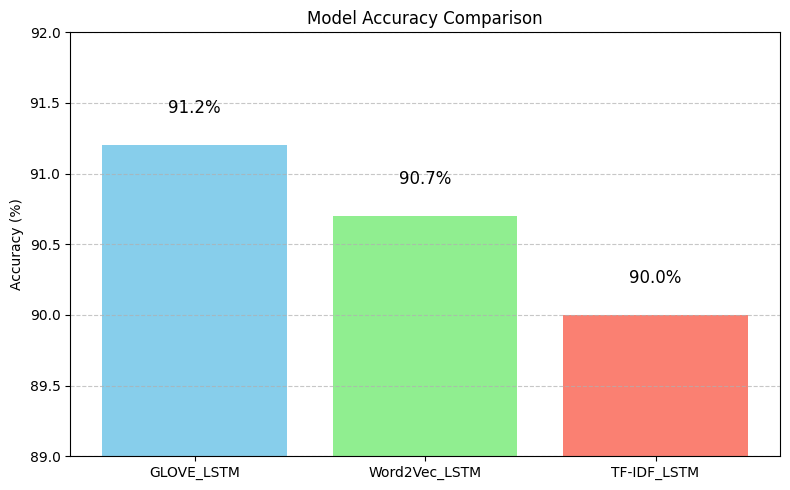

In [ ]:
import matplotlib.pyplot as plt

# Model names and their accuracy scores
models = ['GLOVE_LSTM', 'Word2Vec_LSTM', 'TF-IDF_LSTM']
accuracies = [91.2, 90.7, 90.0]

# Create a bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])

# Add accuracy values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval}%', ha='center', va='bottom', fontsize=12)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(89, 92)  # adjust based on your accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
